/Users/vs479/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


=== Double Logistic (All Data) ===
A=1.001, K1=20.000, r1=0.1241, t1=1917.64, K2=6561.040, r2=0.2183, t2=2013.96
Final carrying capacity = A + K1 + K2 ~ 6582.041

=== Richards Piecewise ===
Wave 1 => A=1.010, K=20.000, r=0.10000, t0=1918.473, nu=0.873
Wave 2 => A=20.000, K=5688.615, r=0.57937, t0=2017.781, nu=0.250


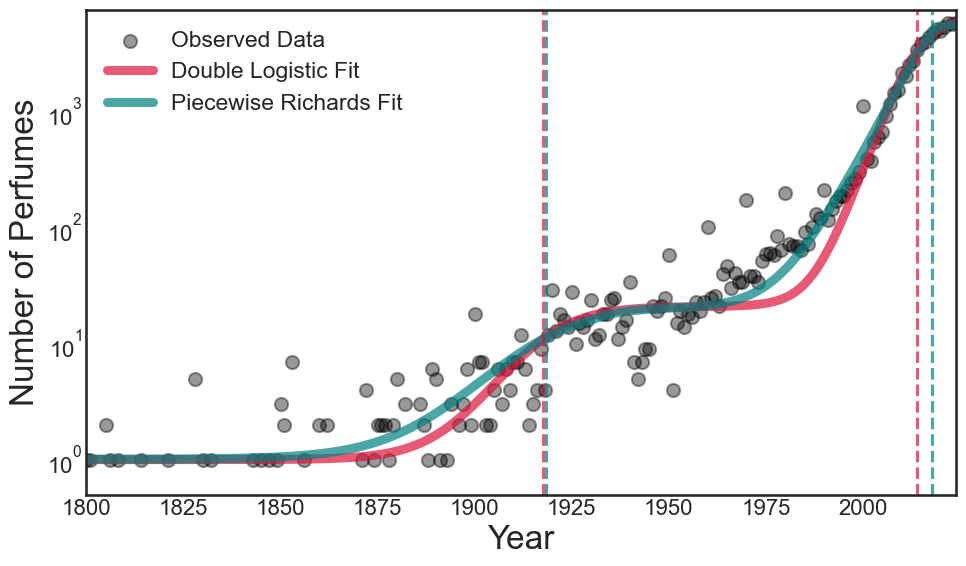

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.nonparametric.smoothers_lowess import lowess
import seaborn as sns

###############################################################################
# 1) READ AND PREPARE DATA
###############################################################################
sns.set_style('white')
sns.set_context('talk')  # slightly larger text
sns.set_palette('Set2')  # nice color palette

df = pd.read_csv("../dataset/perfume_dataset.csv")
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])
df = df[(df['year'] >= 1800) & (df['year'] <= 2024)]
df['year'] = df['year'].astype(int)

# If 'Total' column doesn't exist, compute total perfumes per year
if 'Total' not in df.columns:
    df_total = df.groupby('year').size().rename('Total').reset_index().set_index('year')
else:
    df_total = df.set_index('year')[['Total']]

# (Optional) Remove start-of-decade years if desired:
# df_total = df_total[~(df_total.index % 10 == 0)]

# Convert to numpy arrays
t_data = df_total.index.to_numpy(dtype=float)
N_data = df_total['Total'].to_numpy(dtype=float)

# Sort for stable fitting and plotting
sort_idx = np.argsort(t_data)
t_data_sorted = t_data[sort_idx]
N_data_sorted = N_data[sort_idx]

###############################################################################
# 2) DOUBLE LOGISTIC (WITH FREE LOWER LIMIT) FIT ON ALL DATA
###############################################################################
def double_logistic_lower(t, A, K1, r1, t1, K2, r2, t2):
    """
    Double logistic function with a free lower limit A:
      f(t) = A
           + K1 / (1 + exp(-r1*(t - t1)))
           + K2 / (1 + exp(-r2*(t - t2)))
    """
    term1 = K1 / (1.0 + np.exp(-r1*(t - t1)))
    term2 = K2 / (1.0 + np.exp(-r2*(t - t2)))
    return A + term1 + term2

# Initial guesses & bounds
A_guess  = 1.0
K1_guess = 20
r1_guess = 0.1
t1_guess = 1920
K2_guess = 60000
r2_guess = 0.5
t2_guess = 1950

p0_double = [A_guess, K1_guess, r1_guess, t1_guess, K2_guess, r2_guess, t2_guess]

lower_bounds_double = [1,     19.99,  0,   1910,   0,    0,   1900]
upper_bounds_double = [1.001, 20,     2,   1930, 1e6,    2,   2124]

params_double, _ = curve_fit(
    double_logistic_lower,
    t_data_sorted,
    N_data_sorted,
    p0=p0_double,
    bounds=(lower_bounds_double, upper_bounds_double),
    maxfev=20000
)
A_fit, K1_fit, r1_fit, t1_fit, K2_fit, r2_fit, t2_fit = params_double

###############################################################################
# 3) PIECEWISE RICHARDS FIT (TWO WAVES)
###############################################################################
# 3.1) Split data into wave1 (1800–1950) and wave2 (1930–2024)
mask_wave1 = (t_data_sorted >= 1800) & (t_data_sorted <= 1950)
mask_wave2 = (t_data_sorted >= 1930) & (t_data_sorted <= 2024)

t_wave1 = t_data_sorted[mask_wave1]
N_wave1 = N_data_sorted[mask_wave1]
t_wave2 = t_data_sorted[mask_wave2]
N_wave2 = N_data_sorted[mask_wave2]

def richards(t, A, K, r, t0, nu):
    """
    Richards (generalized logistic) model:
      N(t) = A + (K - A) / [1 + exp(-r*(t - t0))]^(nu)
    """
    return A + (K - A) / (1.0 + np.exp(-r * (t - t0)))**nu

# Wave 1 fit
p0_rich1 = [1, 20, 0.01, 1900, 1.0]
bounds_rich1 = ([1, 10, 0.001, 1850, 0.5],
                [1.01, 20, 0.1, 1950, 5])
params_rich1, _ = curve_fit(richards, t_wave1, N_wave1, p0=p0_rich1,
                            bounds=bounds_rich1, maxfev=10000)
A1, K1, r1, t01, nu1 = params_rich1

# Wave 2 fit
p0_rich2 = [20, 6000, 0.01, 1960, 0.0]
bounds_rich2 = ([10, 3000, 0.001, 1930, 0],
                [20, 700000, 1, 2050, 0.25])
params_rich2, _ = curve_fit(richards, t_wave2, N_wave2, p0=p0_rich2,
                            bounds=bounds_rich2, maxfev=10000)
A2, K2, r2, t02, nu2 = params_rich2

# Define piecewise function
T_low = 1930
T_high = 1950
def piecewise_richards(t):
    t = np.asarray(t)
    y = np.zeros_like(t)
    mask1 = t < T_low
    mask2 = t > T_high
    mask_blend = (t >= T_low) & (t <= T_high)
    
    y[mask1] = richards(t[mask1], A1, K1, r1, t01, nu1)
    y[mask2] = richards(t[mask2], A2, K2, r2, t02, nu2)
    
    if np.any(mask_blend):
        w = (t[mask_blend] - T_low) / (T_high - T_low)
        y1 = richards(t[mask_blend], A1, K1, r1, t01, nu1)
        y2 = richards(t[mask_blend], A2, K2, r2, t02, nu2)
        y[mask_blend] = (1 - w)*y1 + w*y2
    return y

###############################################################################
# 4) PRINT RESULTS
###############################################################################
print("=== Double Logistic (All Data) ===")
print(f"A={A_fit:.3f}, K1={K1_fit:.3f}, r1={r1_fit:.4f}, t1={t1_fit:.2f}, "
      f"K2={K2_fit:.3f}, r2={r2_fit:.4f}, t2={t2_fit:.2f}")
print(f"Final carrying capacity = A + K1 + K2 ~ {A_fit + K1_fit + K2_fit:.3f}")

print("\n=== Richards Piecewise ===")
print(f"Wave 1 => A={A1:.3f}, K={K1:.3f}, r={r1:.5f}, t0={t01:.3f}, nu={nu1:.3f}")
print(f"Wave 2 => A={A2:.3f}, K={K2:.3f}, r={r2:.5f}, t0={t02:.3f}, nu={nu2:.3f}")

###############################################################################
# 5) PLOT BOTH FITS + DATA
###############################################################################
t_fine = np.linspace(t_data_sorted.min(), t_data_sorted.max(), 3000)
N_double = double_logistic_lower(t_fine, *params_double)
N_richards_piecewise = piecewise_richards(t_fine)

plt.figure(figsize=(10, 6))

# Plot data
plt.scatter(t_data_sorted, N_data_sorted, color='k', s=90, alpha=0.4, label='Observed Data')

# Plot double logistic fit
double_color = 'crimson'
plt.plot(t_fine, N_double, color=double_color, lw=6.5, alpha=0.7, label='Double Logistic Fit')

# Plot piecewise Richards fit
richards_color = 'teal'
plt.plot(t_fine, N_richards_piecewise, color=richards_color, lw=6.5, alpha=0.7,
         label='Piecewise Richards Fit')

###############################################################################
# 5.1) ADD VERTICAL LINES AT INFLECTION POINTS
###############################################################################
# Double logistic has t1_fit, t2_fit as inflection points for wave 1 and wave 2
plt.axvline(x=t1_fit, color=double_color, linestyle='--', alpha=0.7)
plt.axvline(x=t2_fit, color=double_color, linestyle='--', alpha=0.7)

# Piecewise Richards has t01 (wave 1) and t02 (wave 2)
plt.axvline(x=t01, color=richards_color, linestyle='--', alpha=0.7)
plt.axvline(x=t02, color=richards_color, linestyle='--', alpha=0.7)

###############################################################################
# 5.2) CUSTOMIZE TICKLINES
###############################################################################
# Make ticks face inward, with minor ticks as well
plt.tick_params(axis='both', which='major', direction='in', length=8, width=1.5)
plt.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0)

# Add a log scale
plt.yscale('symlog', linthresh=0.0001)
plt.ylim(0.5, 1.3 * max(N_data_sorted))
plt.xlim(1800, 2024)

plt.xlabel('Year', fontsize=24)
plt.ylabel('Number of Perfumes', fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(frameon=False)
# plt.title('Double Logistic vs. Piecewise Richards (With Inflection Lines)', fontsize=20)
plt.tight_layout()
plt.savefig("../output/Figure_3a.svg", format="svg", dpi=300)

plt.show()


,Metric,Mean,Median
0,House Career Length,36.403226,28.0
1,Perfumer Career Length,18.037037,15.0
2,Perfumers per House per Year,1.223881,1.0


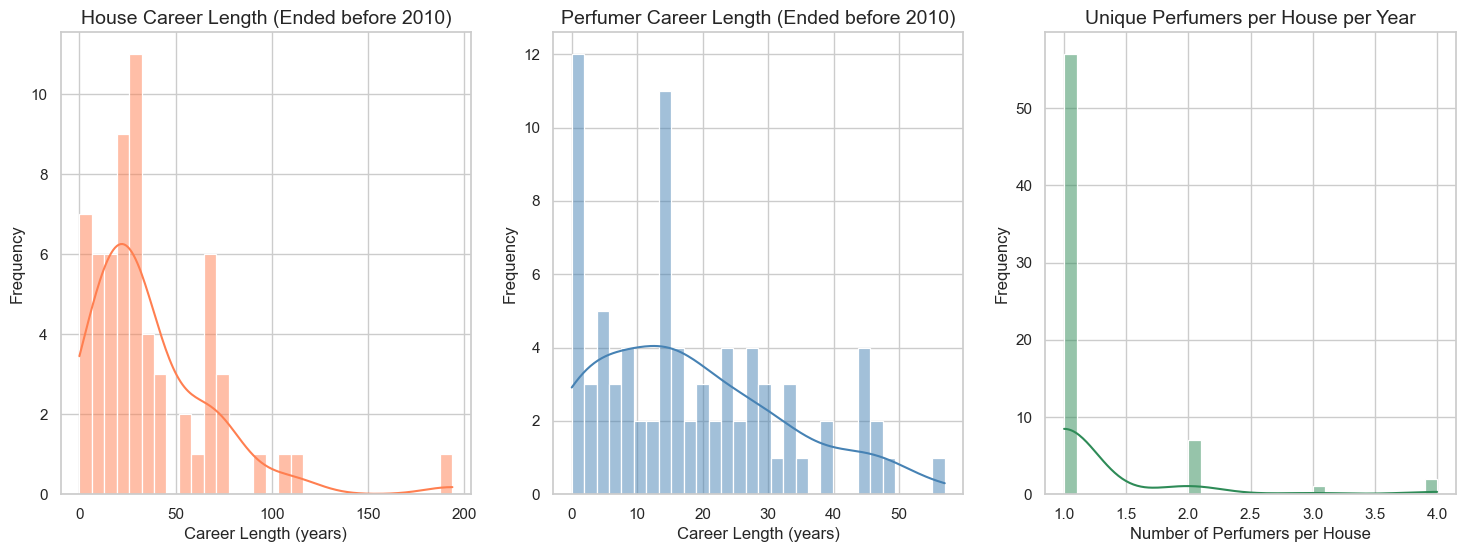

In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# -------------------------
# 1) Read & Prepare the Data
# -------------------------
file_path = "../dataset/perfume_dataset.csv"
data = pd.read_csv(file_path)
year_filter=2010
min_perfumer_filter=5
min_house_filter=10
# Filter data between 1800 and 2024
data = data[(data['year'] >= 1800) & (data['year'] <= 2024)]

# Function to parse perfumers
def parse_perfumer(cell):
    if pd.isna(cell):
        return []
    try:
        perfumers = ast.literal_eval(cell)
        if isinstance(perfumers, list):
            return [name.strip() for name in perfumers if name.strip()]
        else:
            cleaned = str(perfumers).strip()
            return [cleaned] if cleaned else []
    except Exception:
        return [name.strip() for name in cell.split(',') if name.strip()]

data['perfumer'] = data['perfumer'].apply(parse_perfumer)
data['house'] = data['house'].fillna("").apply(lambda x: x.strip())

# Explode so that each row is a single perfumer–perfume pairing
perfumer_exploded = data.explode('perfumer')

# -------------------------
# 2) Filter Valid Entries
# -------------------------
# Filter perfumers with more than 3 perfumes
perfumer_counts = perfumer_exploded['perfumer'].value_counts()
valid_perfumer_names = perfumer_counts[perfumer_counts >=min_perfumer_filter].index
perfumer_exploded = perfumer_exploded[perfumer_exploded['perfumer'].isin(valid_perfumer_names)]

# Define valid houses (houses with at least 10 entries)
house_counts = data['house'].value_counts()
valid_houses = house_counts[house_counts >= min_house_filter].index

# -------------------------
# 3) Compute Career Lengths and Other Metrics
# -------------------------
# a) House Career Lengths
house_career = (
    data[(data['house'] != "") & (data['house'].isin(valid_houses))]
    .groupby('house')['year']
    .agg(['min', 'max'])
    .reset_index()
    .rename(columns={'min': 'first_year', 'max': 'last_year'})
)
# Only include houses that debuted before 2010
house_career = house_career[house_career['last_year'] <year_filter]
house_career['career_length'] = house_career['last_year'] - house_career['first_year']
# Filter out houses with implausibly long careers (600+ years)
house_career = house_career[house_career['career_length'] < 600]
house_mean = house_career['career_length'].mean()
house_median = house_career['career_length'].median()

# b) Perfumer Career Lengths
perfumer_career = (
    perfumer_exploded
    .groupby('perfumer')['year']
    .agg(first_year='min', last_year='max')
    .reset_index()
)
# Only include perfumers who debuted before 2015
perfumer_career = perfumer_career[perfumer_career['last_year'] <year_filter]
perfumer_career['career_length'] = perfumer_career['last_year'] - perfumer_career['first_year']
# Only keep realistic career lengths (< 60 years)
perfumer_career = perfumer_career[perfumer_career['career_length'] < 60]
perfumer_mean = perfumer_career['career_length'].mean()
perfumer_median = perfumer_career['career_length'].median()

# c) Unique Perfumers per House per Year
# Filter valid houses and perfumers based on their career ending before 2010
valid_houses_2010 = house_career[house_career['last_year'] < year_filter]['house']
valid_perfumers_2010 = perfumer_career[perfumer_career['last_year'] < year_filter]['perfumer']

# c) Unique Perfumers per House per Year with the additional filter
perfumers_per_house_year = (
    perfumer_exploded[
        (perfumer_exploded['house'].isin(valid_houses_2010)) &
        (perfumer_exploded['perfumer'].isin(valid_perfumers_2010))
    ]
    .groupby(['house', 'year'])['perfumer']
    .nunique()
    .reset_index(name='num_perfumers')
)

perfumers_mean = perfumers_per_house_year['num_perfumers'].mean()
perfumers_median = perfumers_per_house_year['num_perfumers'].median()

# Create a summary table DataFrame
summary_df = pd.DataFrame({
    'Metric': ['House Career Length', 'Perfumer Career Length', 'Perfumers per House per Year'],
    'Mean': [house_mean, perfumer_mean, perfumers_mean],
    'Median': [house_median, perfumer_median, perfumers_median]
})

# -------------------------
# 4) Plot Distributions Side by Side
# -------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: House Career Length Distribution
sns.histplot(house_career['career_length'], bins=30, kde=True, color="coral", ax=axes[0])
axes[0].set_title("House Career Length (Ended before 2010)", fontsize=14)
axes[0].set_xlabel("Career Length (years)", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

# Plot 2: Perfumer Career Length Distribution
sns.histplot(perfumer_career['career_length'], bins=30, kde=True, color="steelblue", ax=axes[1])
axes[1].set_title("Perfumer Career Length (Ended before 2010)", fontsize=14)
axes[1].set_xlabel("Career Length (years)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Plot 3: Perfumers per House per Year Distribution
sns.histplot(perfumers_per_house_year['num_perfumers'], bins=30, kde=True, color="seagreen", ax=axes[2])
axes[2].set_title("Unique Perfumers per House per Year", fontsize=14)
axes[2].set_xlabel("Number of Perfumers per House", fontsize=12)
axes[2].set_ylabel("Frequency", fontsize=12)

#plt.tight_layout()
#plt.savefig("Distributions_Side_By_Side.svg", format="svg", dpi=300)
#plt.show()

# -------------------------
# 5) Display Summary Table in Jupyter Lab
# -------------------------
display(summary_df)


/var/folders/ts/n9fbfxkj091_fpcsbsgj4zcxb6n5sd/T/ipykernel_29789/2595537259.py:177: RuntimeWarning: divide by zero encountered in divide
  ratio = 1.0 * rolling_active.values / active_houses.values - 1
/var/folders/ts/n9fbfxkj091_fpcsbsgj4zcxb6n5sd/T/ipykernel_29789/2595537259.py:177: RuntimeWarning: invalid value encountered in divide
  ratio = 1.0 * rolling_active.values / active_houses.values - 1


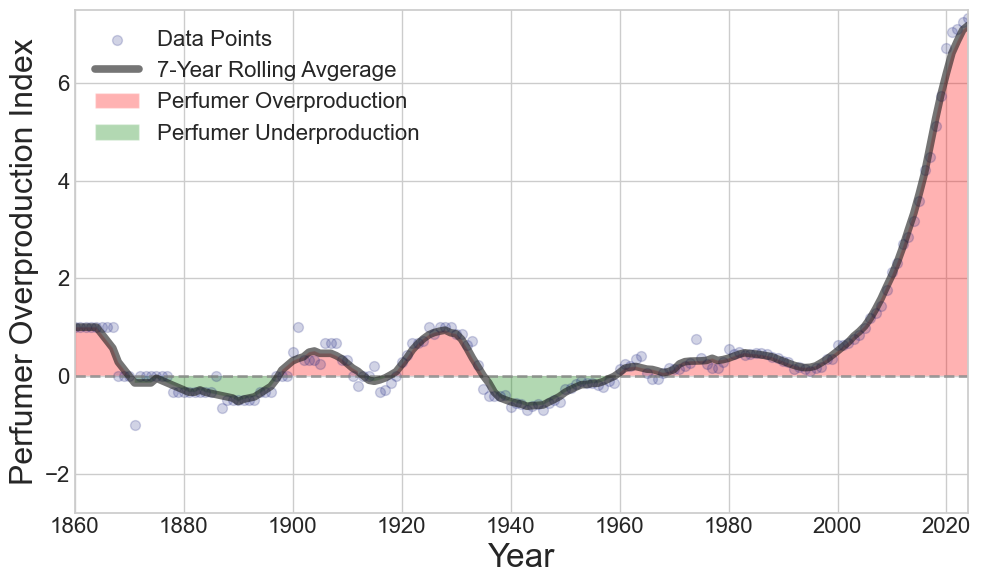

Active Perfumers in 2024: 866
Active Houses in 2024: 104


In [3]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------
# 1) Read & Prepare the Data
# -------------------------
file_path = "../dataset/perfume_dataset.csv"
data = pd.read_csv(file_path)
year_filter=2010
min_perfumer_filter=5
min_house_filter=10
# Filter data between 1800 and 2024
data['year'] = pd.to_numeric(data['year'], errors='coerce')

data = data[(data['year'] >= 1840) & (data['year'] <= 2024)]

# Function to parse perfumers
def parse_perfumer(cell):
    if pd.isna(cell):
        return []
    try:
        perfumers = ast.literal_eval(cell)
        if isinstance(perfumers, list):
            return [name.strip() for name in perfumers if name.strip()]
        else:
            cleaned = str(perfumers).strip()
            return [cleaned] if cleaned else []
    except Exception:
        return [name.strip() for name in cell.split(',') if name.strip()]

data['perfumer'] = data['perfumer'].apply(parse_perfumer)
data['house'] = data['house'].fillna("").apply(lambda x: x.strip())

# Explode so each row is one perfumer–perfume pairing
perfumer_exploded = data.explode('perfumer')

# -------------------------
# Filter for Perfumers with More Than 3 Perfumes
# -------------------------
perfumer_counts = perfumer_exploded['perfumer'].value_counts()
valid_perfumers = perfumer_counts[perfumer_counts >= min_perfumer_filter].index
perfumer_exploded = perfumer_exploded[perfumer_exploded['perfumer'].isin(valid_perfumers)]

# -------------------------
# 2) Count New Perfumers by Year
# -------------------------
# For each perfumer, get earliest (debut) year they appear
perfumer_first_year = (
    perfumer_exploded
    .groupby('perfumer')['year']
    .min()
    .reset_index()
    .rename(columns={'year': 'first_year'})
)

# For each year, count how many perfumers debuted
new_perfumers_by_year = (
    perfumer_first_year
    .groupby('first_year')
    .size()
    .reset_index(name='count')
    .sort_values('first_year')
)

# -------------------------
# 3) Build a Yearly Series from 1800 to 2024 for Perfumers
# -------------------------
all_years = range(1800, 2025)
yearly_new = pd.Series(0, index=all_years)
for _, row in new_perfumers_by_year.iterrows():
    y = int(row['first_year'])
    c = row['count']
    if y in yearly_new.index:
        yearly_new[y] = c

# -------------------------
# 4) Compute "Active" Perfumers with 30-Year Retirement
# -------------------------
# A perfumer is considered active from the year they debut until 30 years later.
rolling_active = pd.Series(0, index=all_years)
running_sum = 0
for y in all_years:
    # Add new perfumers for year y
    running_sum += yearly_new[y]
    # Subtract those whose debut was exactly 30 years ago (they retire after 30 years)
    old_year = y - 15
    if old_year in yearly_new.index:
        running_sum -= yearly_new[old_year]
    rolling_active[y] = running_sum

# # -------------------------
# # 5) Plot Active Perfumers
# # -------------------------
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(12, 6))
# plt.plot(rolling_active.index, 3 * rolling_active.values, marker='o', color='steelblue')
# plt.title("Cumulative Number of Active Perfumers by Year (30-Year Retirement)", fontsize=16)
# plt.xlabel("Year", fontsize=14)
# plt.ylabel("Active Perfumers (Within 30 Years of Debut)", fontsize=14)
# plt.yscale('symlog', linthresh=0.0001)

# plt.ylim(0.5, 4000)
# plt.xlim(1800, 2024)
# plt.tight_layout()
# plt.savefig("Active_Perfumers_30Year_Retirement.svg", format="svg", dpi=300)
# plt.show()

# =============================
# Part B: Active Houses (17-Year Window)
# =============================

# For houses, first exclude empty house entries.
houses_data = data[data['house'] != ""]

# Compute the debut (first appearance) year for each house
house_debut = (
    houses_data
    .groupby('house')['year']
    .min()
    .reset_index()
    .rename(columns={'year': 'first_year'})
)

# Compute the number of unique perfumers per house using the exploded data.
house_perfumers = (
    perfumer_exploded
    .groupby('house')['perfumer']
    .nunique()
    .reset_index()
    .rename(columns={'perfumer': 'unique_perfumer_count'})
)

# Merge house debut info with unique perfumer counts.
house_info = pd.merge(house_debut, house_perfumers, on='house', how='inner')
# Only consider houses with at least 10 unique perfumers.
house_info = house_info[house_info['unique_perfumer_count'] >= min_house_filter]

# Count new houses by their debut year.
new_houses_by_year = (
    house_info
    .groupby('first_year')
    .size()
    .reset_index(name='count')
    .sort_values('first_year')
)

# Build a yearly series for new houses.
yearly_new_houses = pd.Series(0, index=all_years)
for _, row in new_houses_by_year.iterrows():
    y = int(row['first_year'])
    c = row['count']
    if y in yearly_new_houses.index:
        yearly_new_houses[y] = c

# Compute active houses using a 17-year window.
# A house is active from its debut year until 17 years later.
active_houses = pd.Series(0, index=all_years)
running_sum_houses = 0
for y in all_years:
    running_sum_houses += yearly_new_houses[y]
    old_year = y - 28
    if old_year in yearly_new_houses.index:
        running_sum_houses -= yearly_new_houses[old_year]
    active_houses[y] = running_sum_houses

# -------------------------
# 6) Plot Active Houses
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Compute ratio_series and its rolling average as before ---
ratio = 1.0 * rolling_active.values / active_houses.values - 1
ratio_series = pd.Series(ratio, index=active_houses.index)

# Create a full range of years from the minimum to maximum year
all_years = np.arange(ratio_series.index.min(), ratio_series.index.max() + 1)
# Reindex ratio_series to include all years (forward-fill missing values)
ratio_series = ratio_series.reindex(all_years, method='ffill')
# Compute a 7-year rolling average (approximately 5-year smoothing)
rolling_avg = ratio_series.rolling(window=7, center=True, min_periods=0).mean()

# --- Plotting with custom styling similar to your second snippet ---
from matplotlib.patches import Patch

plt.figure(figsize=(10, 6))

# Add a horizontal dashed gray line at y=0
plt.axhline(y=0, color='gray', linestyle='--', lw=2, alpha=0.7)

# Fill areas between the rolling average curve and y=0:
# Fill red where the rolling average is above zero
plt.fill_between(rolling_avg.index, rolling_avg.values, 0,
                 where=(rolling_avg.values >= 0), facecolor='red', alpha=0.3)
# Fill green where the rolling average is below zero
plt.fill_between(rolling_avg.index, rolling_avg.values, 0,
                 where=(rolling_avg.values < 0), facecolor='green', alpha=0.3)

# Scatter plot of raw data (using deep navy)
scatter_handle = plt.scatter(ratio_series.index, ratio_series.values, color='#1a237e', s=50, alpha=0.2, label='Data Points')
# Plot rolling average with a black line
line_handle, = plt.plot(rolling_avg.index, rolling_avg.values, color='k', lw=5.5, alpha=0.6, label='7-Year Rolling Avgerage')

# Create custom legend patches for the fill colors:
red_patch = Patch(facecolor='red', alpha=0.3, label='Perfumer Overproduction')
green_patch = Patch(facecolor='green', alpha=0.3, label='Perfumer Underproduction')

# Combine all legend handles:
handles = [scatter_handle, line_handle, red_patch, green_patch]
plt.legend(handles=handles, frameon=False, fontsize=16)

# Customize axes, scale, and limits
plt.xlabel('Year', fontsize=24)
plt.ylabel('Perfumer Overproduction Index', fontsize=23)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(1860, 2024)
plt.ylim(-2.8, 7.5)
# plt.yscale('symlog', linthresh=0.0001)

# Customize tick lines to face inward
plt.tick_params(axis='both', which='major', direction='in', length=8, width=1.5)
plt.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0)

plt.tight_layout()
plt.savefig("../output/Figure_3b.svg", format="svg", dpi=300)

plt.show()

# -------------------------
# 7) Print Summary Statistics (Optional)
# -------------------------
print("Active Perfumers in 2024:", rolling_active[2024])
print("Active Houses in 2024:", active_houses[2024])
